# Section 2 & 3: Heterogeneity, Evaluation, and Statistical Rigor

Estimates who responds differently to treatment on the clean, randomized data (no induced
confounding here — that was only for Section 1's validation exercise), evaluates the CATE
model honestly against random targeting, segments users, and checks whether the segment-level
findings are statistically defensible.

**Sequence:**
1. Load the Criteo Uplift v2.1 dataset and take a CPU-feasible, clean (non-confounded) subsample.
2. Fit a calibrated T-learner CATE model on a train split, predict on a held-out split.
3. Section 2: evaluate the model with a held-out Qini coefficient against random targeting.
4. Section 2: segment users by clustering on pre-treatment covariates; compute per-segment
   treatment effects with bootstrap CIs.
5. Section 3: apply Benjamini-Hochberg correction across segments.
6. Section 3: per-segment power analysis, anchored to Section 1's ground-truth ATE.
7. Save everything the dashboard's Heterogeneity and Rigor tabs read.

All heavy lifting lives in `src/`; this notebook only calls into it and records results.

In [1]:
import os, sys

_cwd = os.getcwd()
_project_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import json
import os

import numpy as np
import pandas as pd

from src.utils.logging_config import configure_logging
from src.utils.data_loader import load_criteo_uplift
from src.utils.power_analysis import segment_power_analysis
from src.heterogeneity.cate import t_learner_pipeline
from src.heterogeneity.evaluation import evaluate_cate_qini, plot_qini, apply_benjamini_hochberg
from src.heterogeneity.segmentation import cluster_segments, compute_segment_effects

configure_logging()

os.makedirs("../data/processed", exist_ok=True)

FEATURE_COLS = [f"f{i}" for i in range(12)]
RANDOM_STATE = 42  # matches 01_validation.ipynb / 03_sensitivity.ipynb for reproducibility
SUBSAMPLE_N = 500_000  # CPU-feasible subsample for T-learner + Qini + segmentation
N_CLUSTERS = 4
BOOTSTRAP_N = 1000
POWER_THRESHOLD = 0.8
ALPHA = 0.05

2026-09-06 13:34:12,768 INFO src.utils.logging_config: LOGFIRE_TOKEN not set, using console logging fallback


## 1. Load the dataset and take a clean subsample

This is the naturally randomized data, not the artificially confounded sample from Section 1 —
there is no confounding to correct for here, so no induce/calibrate step is needed. `visit` is
the outcome per the Section 1.5 MDE justification; `conversion` is excluded from segment-level
work because it can't support reliable per-segment estimation at CPU-feasible sample sizes.

In [2]:
df = load_criteo_uplift(validate=True)
print(df.shape)

subsample = df.sample(n=SUBSAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(subsample.shape)
print("treatment share:", subsample["treatment"].mean())

2026-09-06 13:34:12,778 INFO src.utils.data_loader: Attempting load from Hugging Face (criteo/criteo-uplift)
2026-09-06 13:34:14,835 INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/criteo/criteo-uplift/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-09-06 13:34:14,889 INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/criteo/criteo-uplift/2424920019e49d52d72c13ac1143ec5d53af276b/README.md?%2Fdatasets%2Fcriteo%2Fcriteo-uplift%2Fresolve%2Fmain%2FREADME.md=&etag=%224b228f4828f61c53d3c1f7743ef3e902426aa365%22 "HTTP/1.1 200 OK"
2026-09-06 13:34:15,156 INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/criteo/criteo-uplift/resolve/2424920019e49d52d72c13ac1143ec5d53af276b/criteo-uplift.py "HTTP/1.1 404 Not Found"
2026-09-06 13:34:15,159 WARNING huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-06 13:

(13979592, 16)
(500000, 16)
treatment share: 0.850002


## 2. Fit the T-learner CATE model

A calibrated T-learner: two per-arm outcome models (treated, control), each calibrated via
`CalibratedClassifierCV` so `predict_proba` outputs are trustworthy probabilities, not just
scores. CATE is predicted only on the held-out split, never on the data the base models saw.

In [3]:
t_learner_result = t_learner_pipeline(
    subsample,
    feature_cols=FEATURE_COLS,
    treatment_col="treatment",
    outcome_col="visit",
    calibrate=True,
    calibration_method="sigmoid",
    cv=3,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

holdout_df = t_learner_result["holdout_df"]
print("Holdout size:", len(holdout_df))
print(
    "Predicted CATE summary: mean=%.5f, std=%.5f"
    % (holdout_df["cate"].mean(), holdout_df["cate"].std())
)

2026-09-06 13:34:22,533 INFO src.heterogeneity.cate: T-learner fit: 297501 treated units, 52499 control units, calibrate=True (method=sigmoid)
2026-09-06 13:34:22,674 INFO src.heterogeneity.cate: Holdout CATE summary: mean=0.00718, std=0.02133, min=-0.08953, max=0.35041


Holdout size: 150000
Predicted CATE summary: mean=0.00718, std=0.02133


## 3. Section 2: Qini evaluation against random targeting

The Qini coefficient measures whether ranking users by predicted CATE actually beats targeting
at random — this is the honesty check the README calls out: the model isn't assumed correct
just because it ran.

c:\Users\abhin\Desktop\Important\codes\projects\causal-inference-lab\venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\abhin\Desktop\Important\codes\projects\causal-inference-lab\venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
2026-09-06 13:34:22,786 INFO src.heterogeneity.evaluation: Qini coefficient: 0.05647


Qini coefficient: 0.05647374887106398
Saved: ../data/processed/qini_curve.json


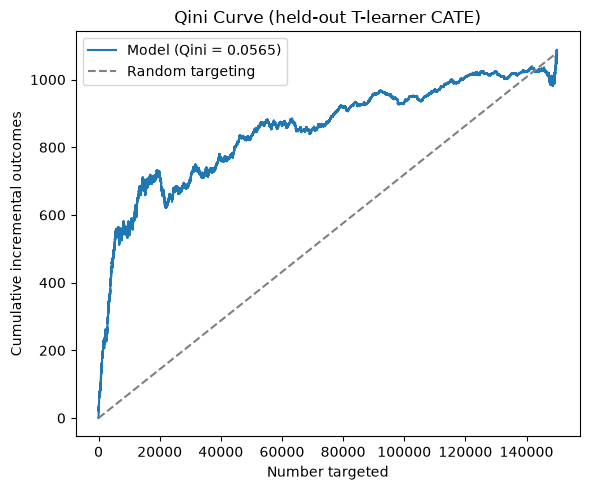

In [4]:
qini_result = evaluate_cate_qini(
    holdout_df,
    cate_col="cate",
    outcome_col="visit",
    treatment_col="treatment",
)
print("Qini coefficient:", qini_result["qini_coefficient"])

fig = plot_qini(qini_result, title="Qini Curve (held-out T-learner CATE)")
fig.savefig("../data/processed/qini_curve.png", dpi=100)

with open("../data/processed/qini_curve.json", "w") as f:
    json.dump(
        {
            "qini_coefficient": float(qini_result["qini_coefficient"]),
            "curve_x": np.asarray(qini_result["curve_x"]).tolist(),
            "curve_y": np.asarray(qini_result["curve_y"]).tolist(),
        },
        f,
    )
print("Saved: ../data/processed/qini_curve.json")

## 4. Section 2: Segment users and compute per-segment effects

Users are clustered on pre-treatment covariates (KMeans, standardized features) rather than
on predicted CATE itself, so segments describe who the users are, not just how the model
scored them. `compute_segment_effects` reports a bootstrap CI per segment and, since a `cate`
column is present, the mean predicted CATE per segment alongside the actual observed effect.

In [5]:
holdout_df = holdout_df.copy()
holdout_df["segment"] = cluster_segments(
    holdout_df, FEATURE_COLS, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE
)

segment_effects_df = compute_segment_effects(
    holdout_df,
    segment_col="segment",
    treatment_col="treatment",
    outcome_col="visit",
    n_bootstrap=BOOTSTRAP_N,
    alpha=ALPHA,
    random_state=RANDOM_STATE,
)
print(segment_effects_df)

2026-09-06 13:34:24,937 INFO src.heterogeneity.segmentation: KMeans clustering: 4 clusters on 150000 rows
2026-09-06 13:34:26,212 INFO src.heterogeneity.segmentation: Computed segment effects for 4 segments


     segment  n_segment  n_treated  n_control  point_estimate  ci_lower  \
0  cluster_0       7259       6247       1012        0.058516  0.040861   
1  cluster_1      77499      65969      11530        0.000226 -0.000860   
2  cluster_2       6192       5260        932        0.044482  0.015037   
3  cluster_3      59050      50024       9026        0.009984  0.004879   

   ci_upper       p_value  mean_predicted_cate  
0  0.076380  1.252752e-07             0.037453  
1  0.001256  6.805783e-01             0.001667  
2  0.075476  7.188825e-03             0.022920  
3  0.015273  5.069407e-04             0.009051  


## 5. Section 3: Benjamini-Hochberg correction

Testing every segment for significance inflates the false-positive rate; BH correction controls
that across all segments at once. `segment_effects.csv` is saved *after* this step so the
dashboard's Section 2 (raw effects) and Section 3 (corrected significance) tabs read the same
file with both raw and corrected columns present.

In [6]:
segment_effects_df = apply_benjamini_hochberg(segment_effects_df, p_value_col="p_value", alpha=ALPHA)
print(
    "Segments significant after correction:",
    int(segment_effects_df["significant_after_correction"].sum()),
    "/",
    len(segment_effects_df),
)

segment_effects_df.to_csv("../data/processed/segment_effects.csv", index=False)
print("Saved: ../data/processed/segment_effects.csv")

Segments significant after correction: 3 / 4
Saved: ../data/processed/segment_effects.csv


## 6. Section 3: Per-segment power analysis

Power is anchored to Section 1's ground-truth ATE (computed on the full 13.9M-row dataset), not
to anything estimated in this notebook, to avoid circularity — using a segment's own effect
estimate to judge whether that segment is well-powered would be circular. If Section 1 hasn't
been run yet, this falls back to the segment-effect median as an explicitly illustrative
(not authoritative) stand-in, and says so in the saved table.

In [7]:
ground_truth_path = "../data/processed/ground_truth.json"
baseline_rate = float(holdout_df.loc[holdout_df["treatment"] == 0, "visit"].mean())
treatment_share = float(holdout_df["treatment"].mean())

if os.path.exists(ground_truth_path):
    with open(ground_truth_path) as f:
        ground_truth = json.load(f)
    true_effect_absolute = float(ground_truth["ate"])
    effect_size_basis = "section_1_ground_truth_ate"
    print(f"Anchoring power analysis to Section 1 ground-truth ATE: {true_effect_absolute:.5f}")
else:
    true_effect_absolute = float(segment_effects_df["point_estimate"].median())
    effect_size_basis = "illustrative_fallback_segment_median"
    print(
        "WARNING: ground_truth.json not found (run 01_validation.ipynb first). Falling back to "
        f"the segment-effect median ({true_effect_absolute:.5f}) as an explicitly illustrative, "
        "less-defensible stand-in."
    )

segment_sizes = segment_effects_df.set_index("segment")["n_segment"].to_dict()

power_df = segment_power_analysis(
    segment_sizes,
    baseline_rate=baseline_rate,
    true_effect_absolute=true_effect_absolute,
    treatment_share=treatment_share,
    alpha=ALPHA,
    power_threshold=POWER_THRESHOLD,
)
power_df["effect_size_basis"] = effect_size_basis
print(power_df)

n_underpowered = int(power_df["underpowered"].sum())
print(f"{n_underpowered} of {len(power_df)} segments underpowered at threshold {POWER_THRESHOLD}")

power_df.to_csv("../data/processed/segment_power.csv", index=False)
print("Saved: ../data/processed/segment_power.csv")

2026-09-06 13:34:26,254 WARNING src.utils.power_analysis: 2 of 4 segments are underpowered (power < 0.80) at effect size 0.01034


Anchoring power analysis to Section 1 ground-truth ATE: 0.01034
     segment  n_segment  n_treatment  n_control  achieved_power  underpowered  \
0  cluster_0       7259         6170       1089        0.329603          True   
1  cluster_1      77499        65874      11625        0.998653         False   
2  cluster_2       6192         5263        929        0.288918          True   
3  cluster_3      59050        50192       8858        0.991110         False   

            effect_size_basis  
0  section_1_ground_truth_ate  
1  section_1_ground_truth_ate  
2  section_1_ground_truth_ate  
3  section_1_ground_truth_ate  
2 of 4 segments underpowered at threshold 0.8
Saved: ../data/processed/segment_power.csv


## Summary

- Fit a calibrated T-learner CATE model on a clean (non-confounded) subsample; predicted only
  on a held-out split.
- Qini coefficient computed against random targeting, so the model's ranking quality is
  evaluated honestly rather than assumed.
- Users segmented by clustering on pre-treatment covariates; per-segment effects computed with
  bootstrap CIs.
- Benjamini-Hochberg correction applied across segments before anything is called significant.
- Per-segment power analysis anchored to Section 1's ground truth (with an explicitly labeled
  fallback if Section 1 hasn't run), flagging which segments are too small to trust.
- Saved `qini_curve.json`, `segment_effects.csv` (raw + BH-corrected columns), and
  `segment_power.csv` for the dashboard.

Next: `03_sensitivity.ipynb` (Section 4, reusing Section 1's matched-pairs sample) and Section 5's
diagnostic critique.